# ConvRNN IT target vs ViT-L static dRSA

Visualizes `static_dRSA_*target_vs_vit_l_16*.npz` files saved under `~/IT_recap_local/results`. The ConvRNN timestep is treated as 10 ms from image onset.

In [1]:
import csv
import os
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml


ENV = os.getenv('MY_ENV', 'tiziano_mac_mini')


@dataclass
class Cfg:
    env: str = ENV
    result_pattern: str = 'static_dRSA_cosine_cnt-cosine_cnt_*target_vs_vit_l_16*.npz'
    timestep_ms: int = 10
    cmap: str = 'viridis'
    line_cmap: str = 'turbo'
    save_figures: bool = True
    figure_dpi: int = 180
    centroid_weight_floor: float = 0.0


cfg = Cfg()
cfg


Cfg(env='tiziano_mac_mini', result_pattern='static_dRSA_cosine_cnt-cosine_cnt_*target_vs_vit_l_16*.npz', timestep_ms=10, cmap='viridis', line_cmap='turbo', save_figures=True, figure_dpi=180, centroid_weight_floor=0.0)

In [2]:
"""
find_project_root
Find the project folder containing config.yaml.

INPUT:
    - start_path: Path -> folder used to start the upward search

OUTPUT:
    - project_root: Path -> project folder
"""
def find_project_root(start_path=Path.cwd()):
    start_path = start_path.resolve()
    search_paths = [start_path] + list(start_path.parents)
    for path in search_paths:
        if (path / 'config.yaml').exists():
            return path
        # end if (path / 'config.yaml').exists():
    # end for path in search_paths:
    fallback = Path.home() / 'Desktop' / 'IT_recap'
    if (fallback / 'config.yaml').exists():
        return fallback
    # end if (fallback / 'config.yaml').exists():
    raise FileNotFoundError('Could not find IT_recap/config.yaml')
# EOF


"""
load_paths
Load path settings for the active environment.

INPUT:
    - project_root: Path -> project folder
    - env: str -> config environment name

OUTPUT:
    - paths: dict -> path settings from config.yaml
"""
def load_paths(project_root, env):
    with open(project_root / 'config.yaml', 'r') as f:
        config = yaml.safe_load(f)
    # end with open(project_root / 'config.yaml', 'r') as f:
    if env not in config:
        raise KeyError(f'{env} is not defined in config.yaml')
    # end if env not in config:
    return config[env]['paths']
# EOF


"""
find_result_file
Find the result file to visualize.

INPUT:
    - cfg: Cfg -> notebook configuration
    - results_dir: Path -> folder containing saved dRSA results

OUTPUT:
    - result_path: Path -> selected result file
"""
def find_result_file(cfg, results_dir):
    result_files = sorted(results_dir.glob(cfg.result_pattern))
    print(f'Found {len(result_files)} matching result files')
    for idx, path in enumerate(result_files):
        print(idx, path.name)
    # end for idx, path in enumerate(result_files):
    if len(result_files) == 0:
        raise FileNotFoundError(
            f'No result files matching {cfg.result_pattern} in {results_dir}'
        )
    # end if len(result_files) == 0:
    return result_files[-1]
# EOF


PROJECT_ROOT = find_project_root()
paths = load_paths(PROJECT_ROOT, cfg.env)
data_path = Path(paths.get('it_recap_data_path', paths['data_path']))
RESULTS_DIR = data_path / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'
RESULT_PATH = find_result_file(cfg, RESULTS_DIR)

print('project root:', PROJECT_ROOT)
print('results dir:', RESULTS_DIR)
RESULT_PATH


Found 1 matching result files
0 static_dRSA_cosine_cnt-cosine_cnt_talia_20each_tizi_rgc_intermediate_conv10_target_vs_vit_l_16_spearman.npz
project root: /Users/tizianocausin/Desktop/IT_recap
results dir: /Users/tizianocausin/IT_recap_local/results


PosixPath('/Users/tizianocausin/IT_recap_local/results/static_dRSA_cosine_cnt-cosine_cnt_talia_20each_tizi_rgc_intermediate_conv10_target_vs_vit_l_16_spearman.npz')

In [3]:
"""
load_drsa_result
Load dRSA results and convert model timesteps to time from image onset.

INPUT:
    - result_path: Path -> .npz result file
    - timestep_ms: int -> milliseconds per ConvRNN timestep

OUTPUT:
    - drsa: np.ndarray -> time x layer similarity matrix
    - time_ms: np.ndarray -> time from image onset in ms
    - layers: np.ndarray -> model layer names
    - best_layer_idx: np.ndarray -> best layer index at each timepoint
    - best_layer_name: np.ndarray -> best layer name at each timepoint
"""
def load_drsa_result(result_path, timestep_ms):
    with np.load(result_path, allow_pickle=True) as result:
        drsa = result['drsa'] if 'drsa' in result.files else result['rsa']
        times = result['times']
        layers = result['model_layers'] if 'model_layers' in result.files else result['vit_layers']
        best_layer_idx = result['best_layer_idx']
        best_layer_name = result['best_layer_name']
    # end with np.load(result_path, allow_pickle=True) as result:
    if drsa.shape != (len(times), len(layers)):
        raise ValueError(f'dRSA shape {drsa.shape} does not match times x layers')
    # end if drsa.shape != (len(times), len(layers)):
    time_ms = times * timestep_ms
    return drsa, time_ms, layers, best_layer_idx, best_layer_name
# EOF


drsa, time_ms, layers, best_layer_idx, best_layer_name = load_drsa_result(
    RESULT_PATH, cfg.timestep_ms
)

print('result:', RESULT_PATH.name)
print('dRSA shape:', drsa.shape)
print('time from image onset (ms):', time_ms)
print('best layers:')
for curr_time, layer, value in zip(
    time_ms, best_layer_name, drsa[np.arange(len(time_ms)), best_layer_idx]
):
    print(f'  {int(curr_time):3d} ms: {layer} ({value:.4f})')
# end for curr_time, layer, value in zip(...)


result: static_dRSA_cosine_cnt-cosine_cnt_talia_20each_tizi_rgc_intermediate_conv10_target_vs_vit_l_16_spearman.npz
dRSA shape: (16, 24)
time from image onset (ms): [100 110 120 130 140 150 160 170 180 190 200 210 220 230 240 250]
best layers:
  100 ms: blocks.10.mlp.fc2 (0.5943)
  110 ms: blocks.12.mlp.fc2 (0.5872)
  120 ms: blocks.12.mlp.fc2 (0.5559)
  130 ms: blocks.14.mlp.fc2 (0.5232)
  140 ms: blocks.14.mlp.fc2 (0.5075)
  150 ms: blocks.14.mlp.fc2 (0.4857)
  160 ms: blocks.13.mlp.fc2 (0.4832)
  170 ms: blocks.13.mlp.fc2 (0.4810)
  180 ms: blocks.13.mlp.fc2 (0.4778)
  190 ms: blocks.13.mlp.fc2 (0.4759)
  200 ms: blocks.13.mlp.fc2 (0.4666)
  210 ms: blocks.13.mlp.fc2 (0.4484)
  220 ms: blocks.13.mlp.fc2 (0.4299)
  230 ms: blocks.13.mlp.fc2 (0.4009)
  240 ms: blocks.13.mlp.fc2 (0.3581)
  250 ms: blocks.13.mlp.fc2 (0.3141)


saved: /Users/tizianocausin/IT_recap_local/results/figures/static_dRSA_cosine_cnt-cosine_cnt_talia_20each_tizi_rgc_intermediate_conv10_target_vs_vit_l_16_spearman_heatmap.png


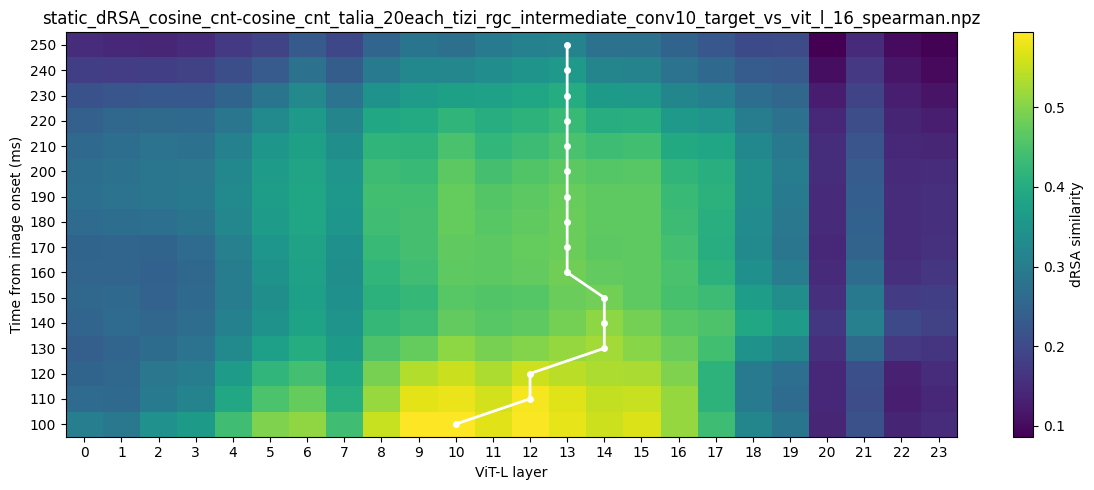

In [4]:
"""
layer_index_labels
Create compact ViT layer labels from layer names.

INPUT:
    - layers: np.ndarray -> layer names

OUTPUT:
    - labels: list[str] -> compact layer labels
"""
def layer_index_labels(layers):
    labels = []
    for layer in layers:
        label = str(layer).replace('blocks.', '').replace('.mlp.fc2', '')
        labels.append(label)
    # end for layer in layers:
    return labels
# EOF


"""
save_figure
Save a Matplotlib figure when requested by the notebook config.

INPUT:
    - fig: matplotlib.figure.Figure -> figure to save
    - figures_dir: Path -> output folder for figure files
    - result_path: Path -> result file used to build the figure
    - suffix: str -> figure-specific filename suffix
    - cfg: Cfg -> notebook configuration

OUTPUT:
    - figure_path: Path | None -> saved figure path, or None if saving is disabled
"""
def save_figure(fig, figures_dir, result_path, suffix, cfg):
    if not cfg.save_figures:
        return None
    # end if not cfg.save_figures:
    figures_dir.mkdir(parents=True, exist_ok=True)
    figure_path = figures_dir / f'{result_path.stem}_{suffix}.png'
    fig.savefig(figure_path, dpi=cfg.figure_dpi, bbox_inches='tight')
    print('saved:', figure_path)
    return figure_path
# EOF


fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(drsa, aspect='auto', origin='lower', cmap=cfg.cmap)
ax.plot(best_layer_idx, np.arange(len(time_ms)), color='white', lw=2, marker='o', ms=4)
ax.set_xlabel('ViT-L layer')
ax.set_ylabel('Time from image onset (ms)')
ax.set_xticks(np.arange(len(layers)))
ax.set_xticklabels(layer_index_labels(layers))
ax.set_yticks(np.arange(len(time_ms)))
ax.set_yticklabels(time_ms)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('dRSA similarity')
ax.set_title(RESULT_PATH.name)
fig.tight_layout()
HEATMAP_PATH = save_figure(fig, FIGURES_DIR, RESULT_PATH, 'heatmap', cfg)


saved: /Users/tizianocausin/IT_recap_local/results/figures/static_dRSA_cosine_cnt-cosine_cnt_talia_20each_tizi_rgc_intermediate_conv10_target_vs_vit_l_16_spearman_vit_layer_timecourses.png


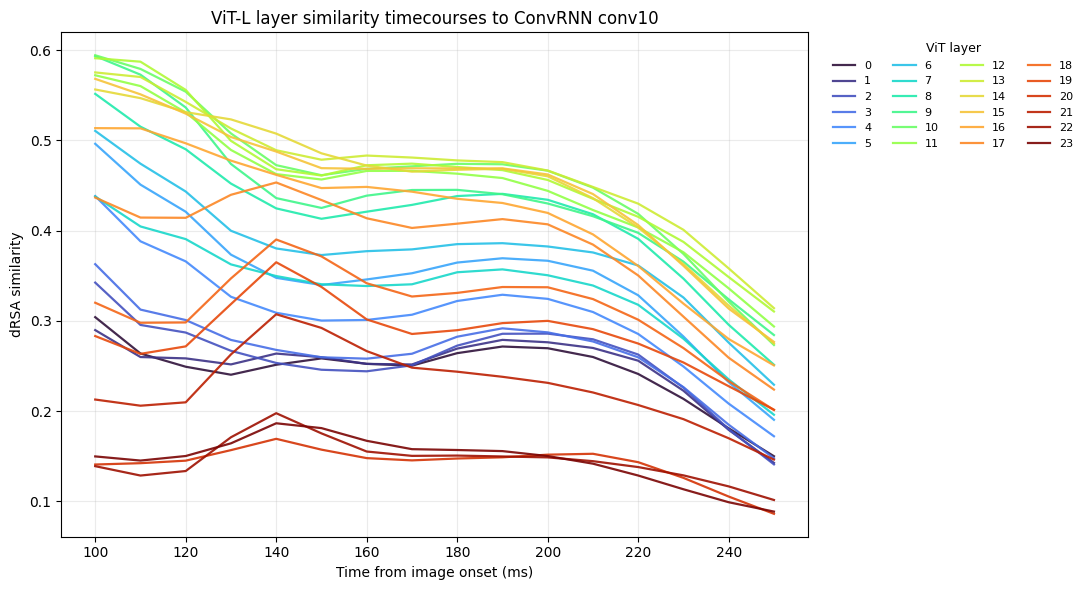

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.get_cmap(cfg.line_cmap)(np.linspace(0, 1, len(layers)))

for layer_idx, (layer, color) in enumerate(zip(layers, colors)):
    ax.plot(
        time_ms,
        drsa[:, layer_idx],
        color=color,
        lw=1.6,
        alpha=0.9,
        label=layer_index_labels([layer])[0],
    )
# end for layer_idx, (layer, color) in enumerate(zip(layers, colors)):

ax.set_xlabel('Time from image onset (ms)')
ax.set_ylabel('dRSA similarity')
ax.set_title('ViT-L layer similarity timecourses to ConvRNN conv10')
ax.grid(True, alpha=0.25)
ax.legend(
    title='ViT layer',
    ncol=4,
    fontsize=8,
    title_fontsize=9,
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
)
fig.tight_layout()
TIMECOURSE_PATH = save_figure(fig, FIGURES_DIR, RESULT_PATH, 'vit_layer_timecourses', cfg)


saved: /Users/tizianocausin/IT_recap_local/results/figures/static_dRSA_cosine_cnt-cosine_cnt_talia_20each_tizi_rgc_intermediate_conv10_target_vs_vit_l_16_spearman_best_layer_timecourse.png


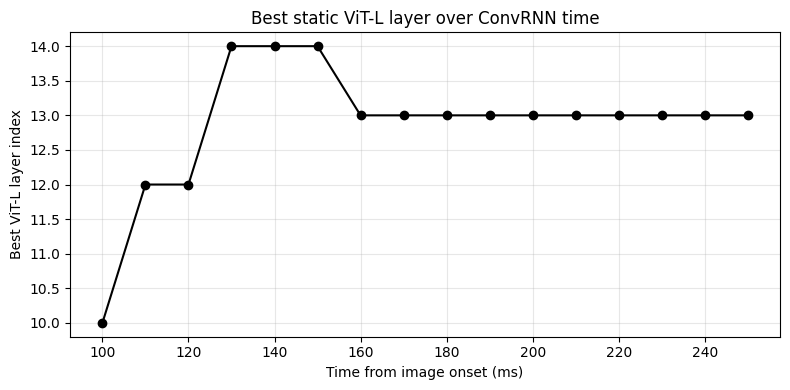

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(time_ms, best_layer_idx, marker='o', color='black')
ax.set_xlabel('Time from image onset (ms)')
ax.set_ylabel('Best ViT-L layer index')
ax.set_title('Best static ViT-L layer over ConvRNN time')
ax.grid(True, alpha=0.3)
fig.tight_layout()
BEST_LAYER_PATH = save_figure(fig, FIGURES_DIR, RESULT_PATH, 'best_layer_timecourse', cfg)


saved: /Users/tizianocausin/IT_recap_local/results/figures/static_dRSA_cosine_cnt-cosine_cnt_talia_20each_tizi_rgc_intermediate_conv10_target_vs_vit_l_16_spearman_vit_layer_centroids.png
saved: /Users/tizianocausin/IT_recap_local/results/figures/static_dRSA_cosine_cnt-cosine_cnt_talia_20each_tizi_rgc_intermediate_conv10_target_vs_vit_l_16_spearman_vit_layer_centroids.csv
  layer 00 blocks.0.mlp.fc2: 170.43 ms
  layer 01 blocks.1.mlp.fc2: 170.74 ms
  layer 02 blocks.2.mlp.fc2: 169.29 ms
  layer 03 blocks.3.mlp.fc2: 168.48 ms
  layer 04 blocks.4.mlp.fc2: 167.14 ms
  layer 05 blocks.5.mlp.fc2: 166.91 ms
  layer 06 blocks.6.mlp.fc2: 168.08 ms
  layer 07 blocks.7.mlp.fc2: 168.14 ms
  layer 08 blocks.8.mlp.fc2: 168.03 ms
  layer 09 blocks.9.mlp.fc2: 167.49 ms
  layer 10 blocks.10.mlp.fc2: 167.47 ms
  layer 11 blocks.11.mlp.fc2: 168.10 ms
  layer 12 blocks.12.mlp.fc2: 168.11 ms
  layer 13 blocks.13.mlp.fc2: 168.77 ms
  layer 14 blocks.14.mlp.fc2: 167.60 ms
  layer 15 blocks.15.mlp.fc2: 167.72

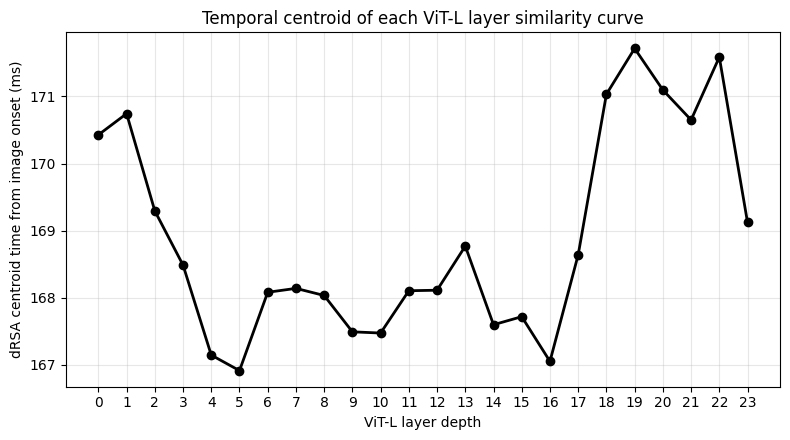

In [8]:
"""
temporal_centroids
Compute the temporal centroid of each layer similarity curve.

INPUT:
    - time_ms: np.ndarray -> time from image onset in ms
    - drsa: np.ndarray -> time x layer similarity matrix
    - weight_floor: float -> minimum similarity value used as centroid weight

OUTPUT:
    - centroids_ms: np.ndarray -> centroid time for each layer in ms
    - weights: np.ndarray -> nonnegative weights used for the centroid
"""
def temporal_centroids(time_ms, drsa, weight_floor=0.0):
    weights = np.array(drsa, dtype=float, copy=True)
    weights[weights < weight_floor] = 0.0
    weight_sums = weights.sum(axis=0)
    centroids_ms = np.full(weights.shape[1], np.nan, dtype=float)
    valid = weight_sums > 0
    centroids_ms[valid] = (
        time_ms[:, None] * weights[:, valid]
    ).sum(axis=0) / weight_sums[valid]
    return centroids_ms, weights
# EOF


"""
save_centroid_table
Save layer centroid values as a small CSV file.

INPUT:
    - figures_dir: Path -> output folder for figure files
    - result_path: Path -> result file used to build the centroid table
    - layer_depths: np.ndarray -> numeric ViT layer depths
    - layers: np.ndarray -> ViT layer names
    - centroids_ms: np.ndarray -> centroid time for each layer in ms
    - cfg: Cfg -> notebook configuration

OUTPUT:
    - table_path: Path | None -> saved CSV path, or None if saving is disabled
"""
def save_centroid_table(figures_dir, result_path, layer_depths, layers, centroids_ms, cfg):
    if not cfg.save_figures:
        return None
    # end if not cfg.save_figures:
    figures_dir.mkdir(parents=True, exist_ok=True)
    table_path = figures_dir / f'{result_path.stem}_vit_layer_centroids.csv'
    with open(table_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['layer_depth', 'layer_name', 'centroid_ms_from_image_onset'])
        for layer_depth, layer, centroid_ms in zip(layer_depths, layers, centroids_ms):
            writer.writerow([int(layer_depth), str(layer), float(centroid_ms)])
        # end for layer_depth, layer, centroid_ms in zip(...):
    # end with open(table_path, 'w', newline='') as f:
    print('saved:', table_path)
    for layer_depth, layer, centroid_ms in zip(layer_depths, layers, centroids_ms):
        print(f'  layer {int(layer_depth):02d} {layer}: {centroid_ms:.2f} ms')
    # end for layer_depth, layer, centroid_ms in zip(...):
    return table_path
# EOF


layer_depths = np.arange(len(layers))
centroids_ms, centroid_weights = temporal_centroids(
    time_ms, drsa, weight_floor=cfg.centroid_weight_floor
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(layer_depths, centroids_ms, marker='o', color='black', lw=2)
ax.set_xlabel('ViT-L layer depth')
ax.set_ylabel('dRSA centroid time from image onset (ms)')
ax.set_xticks(layer_depths)
ax.set_xticklabels(layer_index_labels(layers))
ax.set_title('Temporal centroid of each ViT-L layer similarity curve')
ax.grid(True, alpha=0.3)
fig.tight_layout()
CENTROID_PATH = save_figure(fig, FIGURES_DIR, RESULT_PATH, 'vit_layer_centroids', cfg)
CENTROID_TABLE_PATH = save_centroid_table(
    FIGURES_DIR, RESULT_PATH, layer_depths, layers, centroids_ms, cfg
)
